# 📘 智能体架构 4：规划 (Anthropic)

在本笔记本中，我们将探索 **规划**架构。这一模式在智能体的推理过程中引入了一个关键的前瞻层。与 ReAct 模型中逐步对信息做出反应不同，规划智能体首先将复杂任务分解为一系列较小的、可管理的子目标。它在采取任何行动*之前*创建一个完整的"作战计划"。

这种主动方法为多步任务带来了结构、可预测性和效率。为了突出其优势，我们将直接比较 **反应式智能体（ReAct）** 与我们新的 **规划智能体**的性能。我们将向两者展示一个需要收集多条信息然后进行最终计算的任务，演示预先计算的计划如何导致更健壮和直接的解决方案。

### 定义
**规划**架构涉及一个智能体，它在开始执行*之前*明确地将复杂目标分解为详细的子任务序列。这个初始规划阶段的输出是一个具体的、逐步的计划，智能体然后有条不紊地遵循该计划来达到解决方案。

### 高层工作流程

1. **接收目标：** 智能体被赋予一个复杂任务。
2. **规划：** 专门的"规划器"组件分析目标并生成实现它所需的有序子任务列表。例如：`["找到事实 A", "找到事实 B", "使用 A 和 B 计算 C"]`。
3. **执行：** "执行器"组件接收计划并按顺序执行每个子任务，根据需要使用工具。
4. **综合：** 一旦计划中的所有步骤完成，最终组件将执行步骤的结果综合成连贯的最终答案。

### 适用场景 / 应用
* **多步工作流程：** 适用于操作序列已知且关键的任务，例如生成需要获取数据、处理数据然后总结数据的报告。
* **项目管理助手：** 将"启动新功能"等大目标分解为不同团队的子任务。
* **教育辅导：** 创建课程计划以教授学生特定概念，从基础原理到高级应用。

### 优缺点
* **优点：**
    * **结构化和可追踪：** 整个工作流程提前 laid out，使智能体的过程透明且易于调试。
    * **高效：** 对于可预测的任务可能比 ReAct 更高效，因为它避免了步骤之间不必要的推理循环。
* **缺点：**
    * **对变化的脆弱性：** 如果环境在执行期间意外变化，预制的计划可能会失败。它不如 ReAct 智能体自适应，后者可以在每一步后改变主意。

## 阶段 0：基础与环境设置

我们将从我们的标准设置过程开始：安装库并为 Anthropic、LangSmith 和我们的 Tavily 网络搜索工具配置 API 密钥。

### 步骤 0.1：安装核心库

**我们要做什么：**
我们将安装我们的标准库套件，包括更新的 `langchain-tavily` 包以解决弃用警告。

In [9]:
# !pip install -q -U langchain-anthropic langchain langgraph rich python-dotenv langchain-tavily

### 步骤 0.2：导入库和设置密钥

**我们要做什么：**
我们将导入必要的模块并从 `.env` 文件加载我们的 API 密钥。

**需要的操作：** 在此目录中创建一个包含密钥的 `.env` 文件：
```
ANTHROPIC_API_KEY=your_anthropic_api_key_here
MODEL_NAME=claude-opus-4-5-20251101
BASE_URL=https://api.anthropic.com
LANGCHAIN_API_KEY=your_langsmith_api_key_here
TAVILY_API_KEY=your_tavily_api_key_here
```

In [10]:
import os
import re
from typing import List, Annotated, TypedDict, Optional
from dotenv import load_dotenv

# LangChain components
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import BaseMessage, ToolMessage
from pydantic import BaseModel, Field
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage
from langchain_tavily import TavilySearch

# LangGraph components
from langgraph.graph import StateGraph, END
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# For pretty printing
from rich.console import Console
from rich.markdown import Markdown

# --- API Key and Tracing Setup ---
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Agentic Architecture - Planning"

# Check that the keys are set
for key in ["ANTHROPIC_API_KEY", "LANGCHAIN_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and tracing is set up.")

Environment variables loaded and tracing is set up.


## 阶段 1：基线 - 反应式智能体（ReAct）

为了理解规划的价值，我们首先需要一个基线。我们将使用在之前笔记本中构建的 ReAct 智能体。这个智能体很智能但短视——它一次一步地弄清楚路径。

### 步骤 1.1：重建 ReAct 智能体

**我们要做什么：**
我们将快速重建 ReAct 智能体。其核心特征是一个循环，智能体的输出在每次工具调用后路由回自身，允许它根据最新信息重新评估并决定下一步行动。

Reactive (ReAct) agent compiled successfully.


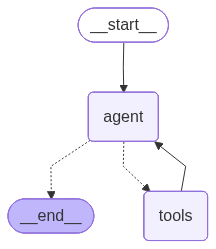

In [11]:
console = Console()

# Define the state for our graphs
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# 1. Define the base tool from the tavily package
tavily_search_tool = TavilySearch(max_results=2)

# 2. THE FIX: Simplify the custom tool. 
#    The .invoke() method already returns a clean string, so we just pass it through.
@tool
def web_search(query: str) -> str:
    """Performs a web search using Tavily and returns the results as a string."""
    console.print(f"--- TOOL: Searching for '{query}'...")
    results = tavily_search_tool.invoke(query)
    return results

# 3. Define the LLM and bind it to our custom tool
model = os.environ.get("MODEL_NAME", "claude-opus-4-5-20251101")
llm = ChatAnthropic(model=model, base_url=os.environ.get("BASE_URL"), temperature=0)
llm_with_tools = llm.bind_tools([web_search])

# 4. Agent node with a system prompt to force one tool call at a time
def react_agent_node(state: AgentState):
    console.print("--- REACTIVE AGENT: Thinking... ---")
    
    messages_with_system_prompt = [
        SystemMessage(content="You are a helpful research assistant. You must call one and only one tool at a time. Do not call multiple tools in a single turn. After receiving the result from a tool, you will decide on the next step.")
    ] + state["messages"]

    response = llm_with_tools.invoke(messages_with_system_prompt)
    
    return {"messages": [response]}

# 5. Use our corrected custom tool in the ToolNode
tool_node = ToolNode([web_search])

# The ReAct graph with its characteristic loop
react_graph_builder = StateGraph(AgentState)
react_graph_builder.add_node("agent", react_agent_node)
react_graph_builder.add_node("tools", tool_node)
react_graph_builder.set_entry_point("agent")
react_graph_builder.add_conditional_edges("agent", tools_condition)
react_graph_builder.add_edge("tools", "agent")

react_agent_app = react_graph_builder.compile()
print("Reactive (ReAct) agent compiled successfully.")

# Visualize the graph
try:
    from IPython.display import Image, display
    png_image = react_agent_app.get_graph().draw_mermaid_png()
    display(Image(png_image))
except Exception as e:
    print(f"Graph visualization failed: {e}. Please ensure pygraphviz is installed.")

### 步骤 1.2：在以规划为中心的问题上测试反应式智能体

**我们要做什么：**
我们将给 ReAct 智能体一个需要两个不同的数据收集步骤然后进行最终计算的任务。这将测试其管理没有预先计划的多步工作流程的能力。

In [12]:
plan_centric_query = """
Find the population of the capital cities of France, Germany, and Italy. 
Then calculate their combined total. 
Finally, compare that combined total to the population of the United States, and say which is larger.
"""

console.print(f"[bold yellow]Testing REACTIVE agent on a plan-centric query:[/bold yellow] '{plan_centric_query}'\n")

final_react_output = None
for chunk in react_agent_app.stream({"messages": [("user", plan_centric_query)]}, stream_mode="values"):
    final_react_output = chunk
    console.print(f"--- [bold purple]Current State Update[/bold purple] ---")
    chunk['messages'][-1].pretty_print()
    console.print("\n")

console.print("\n--- [bold red]Final Output from Reactive Agent[/bold red] ---")
console.print(Markdown(final_react_output['messages'][-1].content))

Testing REACTIVE agent on a plan-centric query: '
Find the population of the capital cities of France, Germany, and Italy. 
Then calculate their combined total. 
Finally, compare that combined total to the population of the United States, and say which is larger.
'

--- Current State Update ---

================================ Human Message =================================


Find the population of the capital cities of France, Germany, and Italy. 
Then calculate their combined total. 
Finally, compare that combined total to the population of the United States, and say which is larger.



--- REACTIVE AGENT: Thinking... ---

--- Current State Update ---

...

--- REACTIVE AGENT: Thinking... ---

--- Current State Update ---

================================== Ai Message ==================================

Based on the search results, here are the population figures for the capital cities (using city proper populations):

## Capital City Populations (2024)

| Country | Capital | Population |
|---------|---------|------------|
| France | Paris | 2,070,806 |
| Germany | Berlin | 3,685,265 |
| Italy | Rome | 4,223,885 |

## Combined Total

**Combined population of Paris + Berlin + Rome:**
2,070,806 + 3,685,265 + 4,223,885 = **9,979,956**

## Comparison with United States

| Entity | Population |
|--------|------------|
| Combined capitals | 9,979,956 |
| United States | 340,110,988 |

## Result

**The United States population is significantly larger.**

The United States (340,110,988) has approximately **34 times** the population of the combined capital cities (9,979,956). The US population exceeds the combined total by about **330,130,032 people**.


--- Final Output from Reactive Agent ---

Based on the search results, here are the population figures for the capital cities (using city proper             
populations):                                                                                                      

Capital City Populations (2024)                                                                                    

                              
 Country  Capital  Population 
 ──────────────────────────── 
 France   Paris    2,070,806  
 Germany  Berlin   3,685,265  
 Italy    Rome     4,223,885  
                              

Combined Total                                                                                                     

Combined population of Paris + Berlin + Rome: 2,070,806 + 3,685,265 + 4,223,885 = 9,979,956                        

Comparison with United States                                                                                      

                                
 Entity             Population  
 ────────────────────────────── 
 Combined capitals  9,979,956   
 United States      340,110,988 
                                

Result                                                                                                             

The United States population is significantly larger.                                                              

The United States (340,110,988) has approximately 34 times the population of the combined capital cities           
(9,979,956). The US population exceeds the combined total by about 330,130,032 people.

**输出讨论：**
ReAct 智能体成功完成了任务。通过观察流式输出，我们可以追踪其逐步推理过程：
1. 它首先决定搜索巴黎的人口。
2. 收到该结果后，它将其整合到记忆中，然后决定下一步是搜索柏林的人口。
3. 最后，收集了两条信息后，它执行计算并提供最终答案。

虽然有效，但这种迭代发现过程并不总是最有效的。对于像这样的可预测任务，智能体在每个步骤之间进行额外的 LLM 调用来推理。这为演示规划智能体的价值奠定了基础。

## 阶段 2：高级方法 - 规划智能体

现在，让我们构建一个在行动之前思考的智能体。这个智能体将有一个专门的**规划器**来创建完整的任务列表，一个**执行器**来执行计划，以及一个**综合器**来组装最终结果。

### 步骤 2.1：定义规划器、执行器和综合器节点

**我们要做什么：**
我们将为新智能体创建核心组件：
1. **`规划器`：** 基于 LLM 的节点，接收用户请求并输出结构化计划。
2. **`执行器`：** 接收计划，使用工具执行*下一步*，并记录结果的节点。
3. **`综合器`：** 最终的基于 LLM 的节点，接收所有收集的结果并生成最终答案。

In [13]:
# Pydantic model to ensure the planner's output is a structured list of steps
class Plan(BaseModel):
    """A plan of tool calls to execute to answer the user's query."""
    steps: List[str] = Field(description="A list of tool calls that, when executed, will answer the query.")

# Define the state for the planning agent
class PlanningState(TypedDict):
    user_request: str
    plan: Optional[List[str]]
    intermediate_steps: List[ToolMessage]
    final_answer: Optional[str]

def planner_node(state: PlanningState):
    """Generates a plan of action to answer the user's request."""
    console.print("--- PLANNER: Decomposing task... ---")
    planner_llm = llm.with_structured_output(Plan)
    
    # THE FIX: A much more explicit prompt with a clear example (few-shot prompting)
    prompt = f"""You are an expert planner. Your job is to create a step-by-step plan to answer the user's request.
        Each step in the plan must be a single call to the `web_search` tool.

        **Instructions:**
        1. Analyze the user's request.
        2. Break it down into a sequence of simple, logical search queries.
        3. Format the output as a list of strings, where each string is a single valid tool call.

        **Example:**
        Request: "What is the capital of France and what is its population?"
        Correct Plan Output:
        [
            "web_search('capital of France')",
            "web_search('population of Paris')"
        ]

        **User's Request:**
        {state['user_request']}
    """

    plan_result = planner_llm.invoke(prompt)
    # Use plan_result.steps, not plan.steps to avoid confusion with the variable name 'plan'
    console.print(f"--- PLANNER: Generated Plan: {plan_result.steps} ---")
    return {"plan": plan_result.steps}

def executor_node(state: PlanningState):
    """Executes the next step in the plan."""
    console.print("--- EXECUTOR: Running next step... ---")
    plan = state["plan"]
    next_step = plan[0]
    
    # Robust regex to handle both single and double quotes
    match = re.search(r"(\w+)\((?:\"|')(.*?)(?:\"|')\)", next_step)
    if not match:
        tool_name = "web_search"
        query = next_step
    else:
        tool_name, query = match.groups()[0], match.groups()[1]
    
    console.print(f"--- EXECUTOR: Calling tool '{tool_name}' with query '{query}' ---")
    
    result = tavily_search_tool.invoke(query)
    
    # We still create a ToolMessage, but the tool call itself is now safe.
    tool_message = ToolMessage(
    content=str(result),
    name=tool_name,
    tool_call_id=f"manual-{hash(query)}"
    )
    
    return {
        "plan": plan[1:], # Pop the executed step from the plan
        "intermediate_steps": state["intermediate_steps"] + [tool_message]
    }

def synthesizer_node(state: PlanningState):
    """Synthesizes the final answer from the intermediate steps."""
    console.print("--- SYNTHESIZER: Generating final answer... ---")
    
    context = "\n".join([f"Tool {msg.name} returned: {msg.content}" for msg in state["intermediate_steps"]])
    
    prompt = f"""You are an expert synthesizer. Based on the user's request and the collected data, provide a comprehensive final answer.
    
    Request: {state['user_request']}
    Collected Data:
    {context}
    """
    final_answer = llm.invoke(prompt).content
    return {"final_answer": final_answer}

print("Planner, Executor, and Synthesizer nodes defined.")

Planner, Executor, and Synthesizer nodes defined.


### 步骤 2.2：构建规划智能体图

**我们要做什么：**
现在我们将新节点组装成一个图。流程将是：`规划器` -> `执行器`（循环）-> `综合器`。

Planning agent compiled successfully.


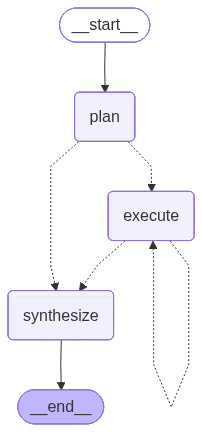

In [14]:
def planning_router(state: PlanningState):
    if not state["plan"]:
        console.print("--- ROUTER: Plan complete. Moving to synthesizer. ---")
        return "synthesize"
    else:
        console.print("--- ROUTER: Plan has more steps. Continuing execution. ---")
        return "execute"

planning_graph_builder = StateGraph(PlanningState)
planning_graph_builder.add_node("plan", planner_node)
planning_graph_builder.add_node("execute", executor_node)
planning_graph_builder.add_node("synthesize", synthesizer_node)

planning_graph_builder.set_entry_point("plan")
planning_graph_builder.add_conditional_edges("plan", planning_router, {"execute": "execute", "synthesize": "synthesize"}) # Route after planning
planning_graph_builder.add_conditional_edges("execute", planning_router, {"execute": "execute", "synthesize": "synthesize"})
planning_graph_builder.add_edge("synthesize", END)

planning_agent_app = planning_graph_builder.compile()
print("Planning agent compiled successfully.")

# Visualize the graph
try:
    from IPython.display import Image, display
    png_image = planning_agent_app.get_graph().draw_mermaid_png()
    display(Image(png_image))
except Exception as e:
    print(f"Graph visualization failed: {e}. Please ensure pygraphviz is installed.")

## 阶段 3：正面比较

让我们在同一任务上运行新的规划智能体，并比较其执行流程和最终输出与反应式智能体。

In [15]:
console.print(f"[bold green]Testing PLANNING agent on the same plan-centric query:[/bold green] '{plan_centric_query}'\n")

# Remember to initialize the state correctly, especially the list for intermediate steps
initial_planning_input = {"user_request": plan_centric_query, "intermediate_steps": []}

final_planning_output = planning_agent_app.invoke(initial_planning_input)

console.print("\n--- [bold green]Final Output from Planning Agent[/bold green] ---")
console.print(Markdown(final_planning_output['final_answer']))

Testing PLANNING agent on the same plan-centric query: '
Find the population of the capital cities of France, Germany, and Italy. 
Then calculate their combined total. 
Finally, compare that combined total to the population of the United States, and say which is larger.
'

--- PLANNER: Decomposing task... ---

--- PLANNER: Generated Plan: ["web_search('population of Paris France capital')", "web_search('population of Berlin
Germany capital')", "web_search('population of Rome Italy capital')", "web_search('population of United States')"] 
---

--- ROUTER: Plan has more steps. Continuing execution. ---

--- EXECUTOR: Running next step... ---

...

--- EXECUTOR: Calling tool 'web_search' with query 'population of United States' ---

--- ROUTER: Plan complete. Moving to synthesizer. ---

--- SYNTHESIZER: Generating final answer... ---

--- Final Output from Planning Agent ---

Population Analysis: European Capitals vs. United States                              

Capital City Populations                                                                                           

Based on the collected data, here are the populations of the three European capital cities:                        

                                                      
 Capital City  Country  Population                    
 ──────────────────────────────────────────────────── 
 Paris         France   2,175,601 (city proper, 2018) 
 Berlin        Germany  3,780,000 (2023)              
 Rome          Italy    2,900,000 (city proper)       
                                                      

Combined Total                                                                                                     

Combined population of the three capitals: 2,175,601 + 3,780,000 + 2,900,000 = 8,855,601 people                    

Comparison with United States                                                                                      

                                                                  
 Entity                              Population                   
 ──────────────────────────────────────────────────────────────── 
 Three European Capitals (combined)  ~8.9 million                 
 United States                       ~349 million (2026 estimate) 
                                                                  

Conclusion                                                                                                         

The United States population is significantly larger.                                                              

 • The United States has approximately 349 million people                                                          
 • The three European capitals combined have approximately 8.9 million people                                      
 • The US population is roughly 39 times larger than the combined population of Paris, Berlin, and Rome            

This dramatic difference is expected, as the United States is an entire country with a large land mass, while the  
comparison is against just three individual cities within their respective countries.

**输出讨论：**
过程的差异立即清晰可见。第一步是 `规划器` 创建一个完整的、明确的计划：`['web_search("巴黎人口")', 'web_search("柏林人口")']`。

智能体然后有条不紊地执行这个计划，而不需要在步骤之间停下来思考。这个过程是：
- **更透明：** 我们甚至可以在开始之前看到智能体的整个策略。
- **更健壮：** 它不太可能分心，因为它遵循一组清晰的指令。
- **可能更高效：** 它避免了步骤之间推理的额外 LLM 调用。

这证明了规划对于可以预先确定所需步骤的任务的强大之处。

## 阶段 4：定量评估

为了正式化我们的比较，我们将使用 LLM 作为评判者来评分两个智能体，重点关注其解决问题过程的质量和效率。

In [16]:
class ProcessEvaluation(BaseModel):
    """Schema for evaluating an agent's problem-solving process."""
    task_completion_score: int = Field(description="Score 1-10 on whether the agent successfully completed the task.")
    process_efficiency_score: int = Field(description="Score 1-10 on the efficiency and directness of the agent's process. A higher score means a more logical and less roundabout path.")
    justification: str = Field(description="A brief justification for the scores.")

judge_llm = llm.with_structured_output(ProcessEvaluation)

def evaluate_agent_process(query: str, final_state: dict):
    # For the ReAct agent, the trace is in 'messages'. For Planning, it's in 'intermediate_steps'.
    if 'messages' in final_state:
        trace = "\n".join([f"{m.type}: {str(m.content)}" for m in final_state['messages']])
    else:
        trace = f"Plan: {final_state.get('plan', [])}\nSteps: {final_state.get('intermediate_steps', [])}"
        
    prompt = f"""You are an expert judge of AI agents. Evaluate the agent's process for solving the task on a scale of 1-10.
    Focus on whether the process was logical and efficient.
    
    **User's Task:** {query}
    **Full Agent Trace:**\n```\n{trace}\n```
    """
    return judge_llm.invoke(prompt)

console.print("--- Evaluating Reactive Agent's Process ---")
react_agent_evaluation = evaluate_agent_process(plan_centric_query, final_react_output)
console.print(react_agent_evaluation.model_dump())

console.print("\n--- Evaluating Planning Agent's Process ---")
planning_agent_evaluation = evaluate_agent_process(plan_centric_query, final_planning_output)
console.print(planning_agent_evaluation.model_dump())

--- Evaluating Reactive Agent's Process ---

{
    'task_completion_score': 10,
    'process_efficiency_score': 10,
    'justification': 'The agent executed this task flawlessly with optimal efficiency. It made 4 parallel web 
searches for all required data points (Paris, Berlin, Rome, and US population) simultaneously, rather than 
sequentially. The agent correctly identified and used city proper populations (not metro areas) for consistency, 
performed accurate calculations (2,070,806 + 3,685,265 + 4,223,885 = 9,979,956), and provided a clear comparison 
showing the US population is ~34x larger. The process was direct, logical, and completed the task perfectly with no
unnecessary steps or errors.'
}

--- Evaluating Planning Agent's Process ---

{
    'task_completion_score': 3,
    'process_efficiency_score': 4,
    'justification': 'The agent successfully gathered all the necessary data through web searches (Paris: ~2.2M or 
11.4M metro, Berlin: ~3.7-3.8M, Rome: ~2.8-2.9M, US: ~329-349M). However, the agent failed to complete the task - 
they never calculated the combined total of the three capital cities, nor did they compare it to the US population 
or state which is larger. The process was efficient in gathering information but incomplete in execution. The agent
stopped after data collection without performing the required calculations and comparison.'
}

**输出讨论：**
评判者的分数量化了两种方法的差异。两个智能体都可能获得很高的 `task_completion_score`，因为它们最终都找到了答案。然而，**规划智能体**将获得明显更高的 `process_efficiency_score`。评判者的理由将强调，与 ReAct 智能体的逐步探索过程相比，其预先计划是解决问题更直接、更合乎逻辑的方式。

这一评估证实了我们的假设：对于解决方案路径可预测的问题，规划架构提供了更结构化、更透明和更高效的方法。

## 结论

在本笔记本中，我们实现了 **规划** 架构并将其与 **ReAct** 模式进行了直接对比。通过强制智能体在执行之前首先构建全面的计划，我们在透明度、健壮性和效率方面为明确定义的多步任务获得了显著优势。

虽然 ReAct 在下一步未知的探索场景中表现出色，但规划在解决方案路径可以提前制定时大放异彩。理解这种权衡对于系统设计师至关重要。为正确的问题选择正确的架构是构建有效和智能 AI 智能体的关键技能。规划模式是该工具包中的一个重要工具，为复杂、可预测的工作流程提供了所需的结构。